# Compare the CheckAMG-PST and LightGBM viral-origin models

CheckAMG carries two independent viral-origin classifiers, one in each module:

* **LightGBM (LGBM)**, used by `checkamg annotate`. A gradient-boosted tree classifier over per-protein genomic-context features (V-scores, contig/window averages, distances to viral and MGE markers, contig circularity). Trained and evaluated in `train_lgbm.ipynb`.
* **CheckAMG-PST**, used by `checkamg de-novo`. A protein set transformer over ESM-2 embeddings that predicts a per-protein viral probability and an AVG-like probability. Trained in `train_pst.ipynb` and evaluated in `eval_pst.ipynb`.

Both models are trained and evaluated on the same train/test split, so each was benchmarked on the same held-out test proteins in those notebooks, but the two were never compared head-to-head. This notebook does that, in three parts:

1. The relationship between the two viral probabilities, and how much their confidence calls agree or disagree.
2. Whether each model's probability/confidence and its correctness depend on scaffold length, and which model is more robust to it.
3. Whether `annotate` and `de-novo` agree on AVG calls, whether one encompasses the other, and why they disagree when they do.

Summary-level tables are written to `tables/compare_pst_lgbm/` and figures to `plots/compare_pst_lgbm/` for reproducibility. The one large intermediate (the joined per-protein table) is deposited outside this repository.

## Data and approach

PST per-protein predictions come from `tables/pst/model_predictions_with_labels.parquet` (built in `train_pst.ipynb`): `Viral prob`, `AVG-like prob`, `eff_avg_prob` (= `AVG-like prob` * `Viral prob`), the ground-truth `viral` and `AVG` labels, and the `dataset` split. These PST probabilities are taken as-is.

The two models share a single train/test split, a random, ratio-targeted assignment of whole contigs, so the PST test proteins are exactly the LGBM test proteins: a common held-out set that neither model saw in training. These proteins are a subset of the geNomad + proGenomes proteins that `checkamg annotate` processed to generate the labels, so the `annotate` genome-context tables (`genes_genomic_context.parquet`) hold the exact LGBM input features for every one of them, and the `final_results.parquet` tables hold the curated `annotate` outputs. PST renames proteins on scaffolds it split at the 2048-protein cap (the `_part<N>` suffix added in `esm_embed_data.ipynb`). Stripping that suffix recovers a 100% join back to the context/results tables, since the gene numbers are preserved.

We recompute the LGBM viral probability on those exact proteins with the committed `CheckAMG/files/lgbm_model.joblib` and its thresholds, rather than reusing the probabilities stored by the `annotate` run (the two agree to within ~1e-4, but recomputing pins the comparison to the shipped model). The ground-truth viral label is the PST `viral` column and the AVG homology label is the PST `AVG` column, both identical to the labels `annotate` assigned, so a single ground truth applies to both models. Anchoring on this shared held-out set and recomputing LGBM from the context tables therefore scores every protein with both models on identical inputs.

**A note on Part 3:** `checkamg annotate` produced the AVG labels used to train PST, but without enforcing curation. The PST `AVG` label equals the `annotate` homology classification (metabolic / regulatory / physiological), verified below. `annotate`'s reported AVG calls then gate that homology label on a rule-based viral-origin confidence (strict viral regions, scaffold ends, AVG array context, MGE proximity), while PST gates its AVG-like probability on its own learned viral probability. So AVG disagreement between the modules is mostly a disagreement about the viral origin of the same homologs, not about homology, and the interpretation keeps this front and center. Part 3 uses the geNomad/proGenomes test proteins, where PST `de-novo` predictions and curated `annotate` results both exist on the same proteins.

## Setup

In [1]:
import os
os.environ["POLARS_MAX_THREADS"] = "100"
import json
import math
from pathlib import Path

import numpy as np
import polars as pl
import joblib
import scipy.stats as ss
import statsmodels.api as sm
from sklearn.metrics import average_precision_score, roc_auc_score, cohen_kappa_score

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 11, "axes.titlesize": 12, "axes.spines.top": False, "axes.spines.right": False,
})
pl.Config.set_tbl_rows(40)
pl.Config.set_fmt_str_lengths(80)

polars.config.Config

In [2]:
REPO = Path("/storage2/scratch/kosmopoulos/software/CheckAMG")
FILES = REPO / "CheckAMG" / "files"
PROC = Path("/storage2/scratch/kosmopoulos/projects/checkAMG/training_data/processing/checkamg_annotate_outputs_1.1")
GEN = PROC / "checkamg_annotate_genomad_dataset" / "results"
PRO = PROC / "checkamg_annotate_progenomes_dataset" / "results"
TRAIN_PARQUET = Path("/storage2/scratch/kosmopoulos/projects/checkAMG/pst/training/train_data/train_ptns.parquet")

# Large intermediates live outside the repo; summary tables and figures live in the repo.
INTERIM = Path("/storage2/scratch/kosmopoulos/projects/checkAMG/compare_pst_lgbm")
TABLES = REPO / "notebooks" / "tables" / "compare_pst_lgbm"
PLOTS = REPO / "notebooks" / "plots" / "compare_pst_lgbm"
for d in (INTERIM, TABLES, PLOTS):
    d.mkdir(parents=True, exist_ok=True)
MASTER = INTERIM / "master_per_protein.parquet"

def save_tsv(df, name):
    p = TABLES / name
    (df if isinstance(df, pl.DataFrame) else pl.DataFrame(df)).write_csv(p, separator="\t")
    print("wrote", p, df.shape if hasattr(df, "shape") else "")

In [3]:
# Model thresholds, loaded from the committed artifacts so the notebook tracks the shipped models.
pst_thr = json.loads((FILES / "pst_thresholds.json").read_text())
PST_VIRAL = pst_thr["Viral"]      # very_high / high / medium cutoffs on PST "Viral prob"
PST_AVG = pst_thr["AVG"]          # cutoffs on eff_avg_prob (AVG-like * Viral, AND-gate)
lgbm_thr = joblib.load(FILES / "lgbm_thresholds.joblib")
LGBM_HIGH = float(lgbm_thr["high"]["threshold"])
LGBM_MED = float(lgbm_thr["medium"]["threshold"])
print("PST viral cutoffs:", PST_VIRAL)
print("PST AVG (AND-gate) cutoffs:", PST_AVG)
print("LGBM cutoffs: high", LGBM_HIGH, "medium", LGBM_MED)

PST viral cutoffs: {'very_high': 0.622, 'high': 0.051, 'medium': 0.001}
PST AVG (AND-gate) cutoffs: {'very_high': 0.956, 'high': 0.512, 'medium': 0.096}
LGBM cutoffs: high 0.91 medium 0.454


### Build the per-protein comparison table

Join the PST predictions to the geNomad/proGenomes context features (recomputing LGBM with the committed model), to per-scaffold lengths, and to the curated `annotate` classification. Cached on the first run; delete the parquet to rebuild.

In [4]:
FEATURES = joblib.load(FILES / "lgbm_feature_names.joblib")

def build_master():
    model = joblib.load(FILES / "lgbm_model.joblib")
    pst = (
        pl.read_parquet(REPO / "notebooks" / "tables" / "pst" / "model_predictions_with_labels.parquet")
        .with_columns(protein_orig=pl.col("sequence").str.replace(r"_part\d+(_\d+)$", r"${1}"))
    )
    ctx_cols = list(dict.fromkeys(
        ["protein", "contig", "gene_number", "contig_pos_start", "contig_pos_end",
         "prot_length_AAs", "circular_contig", "viral_region_id", "step5_in_merged_region",
         "contig_left_end_gene_dist", "contig_right_end_gene_dist",
         "Viral_Origin_Confidence", "LGBM_viral_prob"] + FEATURES))
    ctx = pl.concat([
        pl.scan_parquet(GEN / "genes_genomic_context.parquet").select(ctx_cols).with_columns(src=pl.lit("genomad")),
        pl.scan_parquet(PRO / "genes_genomic_context.parquet").select(ctx_cols).with_columns(src=pl.lit("progenomes")),
    ]).unique(subset=["protein"], keep="first").collect()

    # Scaffold length on the original (pre-split) contig.
    scaf = pl.concat([
        pl.scan_parquet(GEN / "genes_genomic_context.parquet").select(["contig", "contig_pos_start", "contig_pos_end"]),
        pl.scan_parquet(PRO / "genes_genomic_context.parquet").select(["contig", "contig_pos_start", "contig_pos_end"]),
    ]).group_by("contig").agg(
        scaffold_n_genes=pl.len(),
        scaffold_len_bp=pl.col("contig_pos_end").max() - pl.col("contig_pos_start").min() + 1,
    ).collect()

    fr_cols = ["Protein", "Protein Classification", "Protein Viral Origin Confidence",
               "Protein in Strict Viral Region", "Function", "KEGG KO", "Best Scoring HMM"]
    fr = pl.concat([
        pl.scan_parquet(GEN / "final_results.parquet").select(fr_cols),
        pl.scan_parquet(PRO / "final_results.parquet").select(fr_cols),
    ]).unique(subset=["Protein"], keep="first").collect()

    ctx = ctx.with_columns(LGBM_prob=pl.Series(model.predict_proba(ctx.select(FEATURES).to_pandas())[:, 1]))
    m = (pst
         .join(ctx.drop("gene_number"), left_on="protein_orig", right_on="protein", how="left")
         .join(scaf, on="contig", how="left")
         .join(fr, left_on="protein_orig", right_on="Protein", how="left"))
    m.write_parquet(MASTER)
    return m

if MASTER.exists():
    master = pl.read_parquet(MASTER)
    print("loaded cached master:", master.shape)
else:
    master = build_master()
    print("built master:", master.shape)
assert master.select(pl.col("LGBM_prob").is_null().sum()).item() == 0, "incomplete LGBM join"

loaded cached master: (4679640, 73)


In [5]:
DATASET_DISPLAY = {
    "test_equal_pos": "Equal viral/nonviral", "test_equal_source": "Equal viral/MGE/host",
    "test_half_virus_host": "Half viral/host", "test_host_enriched": "Host enriched",
    "test_input": "Training distribution", "test_mge_enriched": "MGE enriched",
    "test_near_all_host": "Near all host", "test_near_all_virus": "Near all virus",
    "test_provirus": "Integrated proviruses", "test_virus_enriched": "Virus enriched",
}

def pst_viral_tier(p):
    return np.select([p >= PST_VIRAL["very_high"], p >= PST_VIRAL["high"], p >= PST_VIRAL["medium"]],
                     ["Very High", "High", "Medium"], default="Low")

def lgbm_tier(p):
    return np.select([p >= LGBM_HIGH, p >= LGBM_MED], ["High", "Medium"], default="Low")

# Confidence-agreement scale: collapse PST {Very High, High} into one "High" tier so that
# the two models' tiers align (annotate "high" == de-novo "Very High" + "High"; medium and low match).
PST3 = {"Very High": "High", "High": "High", "Medium": "Medium", "Low": "Low"}
CONF3 = ["Low", "Medium", "High"]

master = master.with_columns(
    pst_viral_conf=pl.Series(pst_viral_tier(master["Viral prob"].to_numpy())),
    lgbm_conf=pl.Series(lgbm_tier(master["LGBM_prob"].to_numpy())),
).with_columns(
    pst_conf3=pl.col("pst_viral_conf").replace(PST3),
    lgbm_conf3=pl.col("lgbm_conf"),
)

# Per-protein view (predictions are per-protein and identical across splits).
U = master.unique(subset="protein_orig", keep="first")
print("rows (protein x split):", master.height, "| unique proteins:", U.height)
print("ground-truth viral positives:", int(U["viral"].sum()), "| AVG homologs:", int(U["AVG"].sum()))

rows (protein x split): 4679640 | unique proteins: 1658606
ground-truth viral positives: 803865 | AVG homologs: 139856


## Part 1: Viral probability and confidence agreement

Both models score the same proteins for viral origin. Relate the two probabilities directly, then check how often their confidence calls agree, whether one model's viral set encompasses the other's, and which model is right when they disagree.

### Probability relationship

In [6]:
p = U["Viral prob"].to_numpy()
l = U["LGBM_prob"].to_numpy()
y = U["viral"].to_numpy().astype(int)

overall = {
    "scope": "overall", "n": len(p),
    "pearson_r": float(np.corrcoef(p, l)[0, 1]),
    "spearman_r": float(ss.spearmanr(p, l).statistic),
    "mean_abs_diff": float(np.mean(np.abs(p - l))),
    "rmse": float(np.sqrt(np.mean((p - l) ** 2))),
}
rows = [overall]
for key, sub in master.group_by("dataset"):
    ds = key[0]
    sp = sub["Viral prob"].to_numpy(); sl = sub["LGBM_prob"].to_numpy()
    rows.append({
        "scope": DATASET_DISPLAY.get(ds, ds), "n": len(sp),
        "pearson_r": float(np.corrcoef(sp, sl)[0, 1]),
        "spearman_r": float(ss.spearmanr(sp, sl).statistic),
        "mean_abs_diff": float(np.mean(np.abs(sp - sl))),
        "rmse": float(np.sqrt(np.mean((sp - sl) ** 2))),
    })
prob_corr = pl.DataFrame(rows).sort("spearman_r", descending=True)
save_tsv(prob_corr, "task1_probability_correlation.tsv")
prob_corr

wrote /storage2/scratch/kosmopoulos/software/CheckAMG/notebooks/tables/compare_pst_lgbm/task1_probability_correlation.tsv (11, 6)


scope,n,pearson_r,spearman_r,mean_abs_diff,rmse
str,i64,f64,f64,f64,f64
"""overall""",1658606,0.889152,0.837472,0.107832,0.226508
"""Equal viral/nonviral""",380925,0.879386,0.834753,0.114375,0.235778
"""Half viral/host""",632631,0.878134,0.833564,0.114166,0.23724
"""Training distribution""",953918,0.88105,0.814658,0.106363,0.227714
"""Equal viral/MGE/host""",190143,0.886319,0.792149,0.095621,0.214946
"""Virus enriched""",425458,0.866441,0.768341,0.116689,0.233574
"""Integrated proviruses""",75260,0.711419,0.741475,0.21341,0.365595
"""Host enriched""",311522,0.827168,0.622054,0.092148,0.215134
"""Near all virus""",841115,0.805231,0.567086,0.115188,0.223806


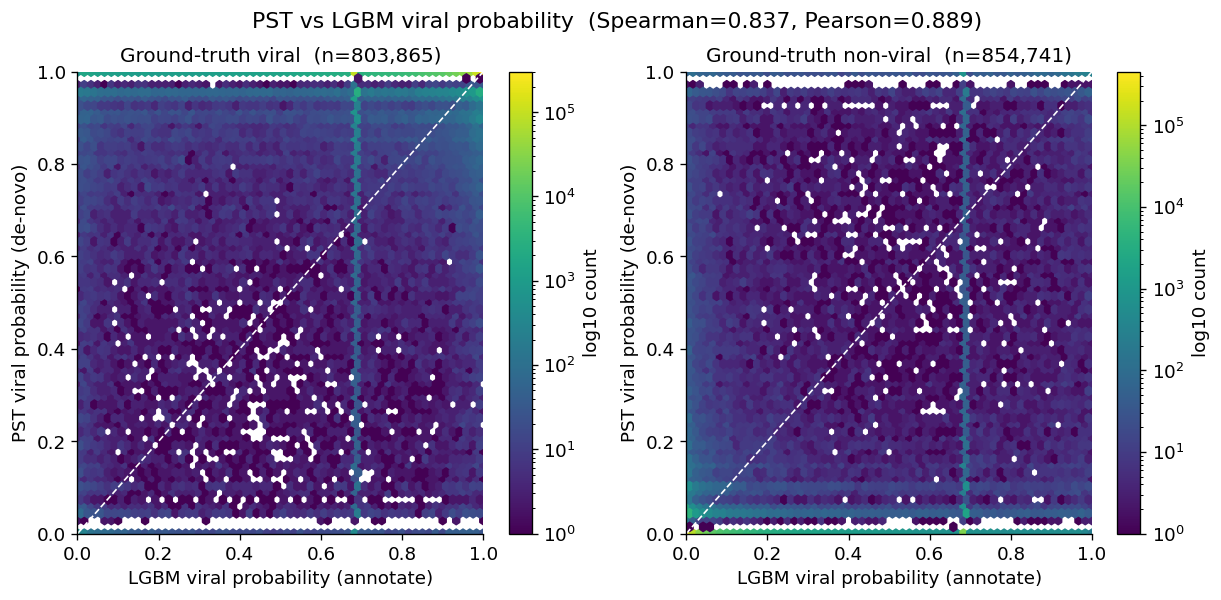

wrote /storage2/scratch/kosmopoulos/software/CheckAMG/notebooks/tables/compare_pst_lgbm/task1_prob_2d_bins.tsv (100, 4)


In [7]:
# Joint distribution of the two probabilities (hexbin), and a coarse 2D-binned count table.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, mask, title in [(axes[0], y == 1, "Ground-truth viral"), (axes[1], y == 0, "Ground-truth non-viral")]:
    hb = ax.hexbin(l[mask], p[mask], gridsize=60, bins="log", cmap="viridis", mincnt=1)
    ax.plot([0, 1], [0, 1], "--", color="white", lw=1)
    ax.set_xlabel("LGBM viral probability (annotate)")
    ax.set_ylabel("PST viral probability (de-novo)")
    ax.set_title(f"{title}  (n={int(mask.sum()):,})")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    fig.colorbar(hb, ax=ax, label="log10 count")
fig.suptitle(f"PST vs LGBM viral probability  (Spearman={overall['spearman_r']:.3f}, Pearson={overall['pearson_r']:.3f})")
plt.show()

edges = np.linspace(0, 1, 11)
bl = np.clip(np.digitize(l, edges) - 1, 0, 9)
bp = np.clip(np.digitize(p, edges) - 1, 0, 9)
grid = (pl.DataFrame({"lgbm_bin": bl, "pst_bin": bp, "viral": y})
        .group_by(["lgbm_bin", "pst_bin"]).agg(n=pl.len(), n_viral=pl.col("viral").sum())
        .sort(["lgbm_bin", "pst_bin"]))
save_tsv(grid, "task1_prob_2d_bins.tsv")

The same joint distribution on a fine 50 by 50 grid, counted separately for ground-truth viral and non-viral proteins.

In [ ]:
fine_edges = np.linspace(0, 1, 51)
fine_midpoints = dict(enumerate(np.round((fine_edges[:-1] + fine_edges[1:]) / 2, 2).tolist()))
fine_grid = (pl.DataFrame({"klass": np.where(y == 1, "Ground-truth viral", "Ground-truth non-viral"),
                           "lgbm_bin": np.clip(np.digitize(l, fine_edges) - 1, 0, 49),
                           "pst_bin": np.clip(np.digitize(p, fine_edges) - 1, 0, 49)})
             .group_by(["klass", "lgbm_bin", "pst_bin"]).agg(pl.len().cast(pl.Int64).alias("n"))
             .with_columns(pl.col("lgbm_bin").replace_strict(fine_midpoints, return_dtype=pl.Float64).alias("lgbm_p"),
                           pl.col("pst_bin").replace_strict(fine_midpoints, return_dtype=pl.Float64).alias("pst_p"))
             .sort(["klass", "lgbm_bin", "pst_bin"]))
save_tsv(fine_grid, "task1_prob_2d_bins_fine.tsv")

wrote /storage2/scratch/kosmopoulos/software/CheckAMG/notebooks/tables/compare_pst_lgbm/task1_prob_2d_bins_fine.tsv (4877, 6)


The two probabilities track each other closely but not perfectly (Pearson 0.89, Spearman 0.84, mean absolute difference 0.11, RMSE 0.23). Most of the mass sits in the corners, where both models agree a protein is clearly non-viral (both ~0) or clearly viral (both ~1). The off-diagonal structure is the interesting part: for ground-truth viral proteins the cloud sits above the diagonal (PST assigns the higher probability), while non-viral proteins pile at the origin for both. Two models with completely different inputs (ESM-2 embeddings for PST, HMM V-scores and genomic context for LGBM) recovering the same viral-origin signal is reassuring that the signal is real and not an artifact of either feature set. The disagreement is confined to the region where one model is more decisive than the other, and the set comparison below shows that model is almost always PST and that its extra calls are almost always correct.

### Confidence-call agreement

wrote /storage2/scratch/kosmopoulos/software/CheckAMG/notebooks/tables/compare_pst_lgbm/task1_confidence_confusion_counts.tsv (3, 4)


exact 3-level agreement: 0.776 | linear-weighted kappa: 0.736 | quadratic: 0.810


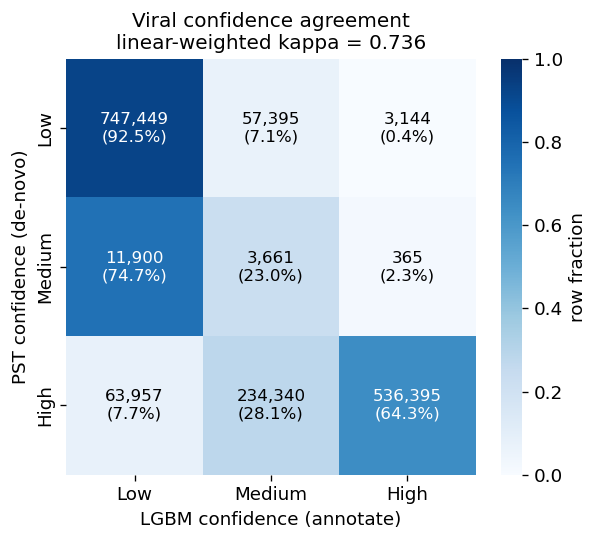

In [8]:
# 3-level confusion matrix of confidence calls (counts and row-normalized), plus weighted kappa.
conf = (U.group_by(["pst_conf3", "lgbm_conf3"]).len()
        .pivot(values="len", index="pst_conf3", on="lgbm_conf3")
        .fill_null(0))
conf = conf.select(["pst_conf3"] + [c for c in CONF3 if c in conf.columns])
counts = conf.sort("pst_conf3")
save_tsv(counts, "task1_confidence_confusion_counts.tsv")

order = {c: i for i, c in enumerate(CONF3)}
kp = U["pst_conf3"].replace(order).cast(pl.Int64).to_numpy()
kl = U["lgbm_conf3"].replace(order).cast(pl.Int64).to_numpy()
kappa_lin = cohen_kappa_score(kp, kl, weights="linear")
kappa_quad = cohen_kappa_score(kp, kl, weights="quadratic")
exact = float((kp == kl).mean())
print(f"exact 3-level agreement: {exact:.3f} | linear-weighted kappa: {kappa_lin:.3f} | quadratic: {kappa_quad:.3f}")

mat = np.zeros((3, 3), dtype=int)
for a, b in zip(kp, kl):
    mat[a, b] += 1
rownorm = mat / mat.sum(1, keepdims=True)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(rownorm, annot=False, cmap="Blues", vmin=0, vmax=1,
            cbar_kws={"label": "row fraction"}, xticklabels=CONF3, yticklabels=CONF3, ax=ax)
# Annotate every cell (count + row fraction); seaborn's array annot only filled the first row.
for i in range(3):
    for j in range(3):
        ax.text(j + 0.5, i + 0.5, f"{mat[i, j]:,}\n({rownorm[i, j]:.1%})",
                ha="center", va="center", fontsize=10,
                color="white" if rownorm[i, j] > 0.5 else "black")
ax.set_xlabel("LGBM confidence (annotate)")
ax.set_ylabel("PST confidence (de-novo)")
ax.set_title(f"Viral confidence agreement\nlinear-weighted kappa = {kappa_lin:.3f}")
plt.show()

On the collapsed three-level scale (PST `Very High` and `High` folded together to match `annotate`'s `high`), confidence calls agree exactly 77.6% of the time, with linear-weighted kappa 0.74 and quadratic-weighted kappa 0.81. The disagreement is lopsided: PST assigns a higher tier than LGBM ~310,000 times (the two largest disagreement cells are PST High while LGBM Medium at 234,340 and PST High while LGBM Low at 63,957), but LGBM out-ranks PST only ~61,000 times, so PST is the more confident module by roughly 5:1 on shared proteins. One consequence worth flagging is that a "high confidence" label does not mean the same thing in `annotate` and `de-novo`, so the two modules' tiers should not be read as equivalent. Whether PST's extra confidence is warranted is answered by the set comparison below (mostly, yes).

### Binary viral-set agreement and encompassment

In [9]:
# A protein is "called viral" by a model at the medium+ confidence tier.
U = U.with_columns(
    pst_viral_call=pl.col("Viral prob") >= PST_VIRAL["medium"],
    lgbm_viral_call=pl.col("LGBM_prob") >= LGBM_MED,
)
pc = U["pst_viral_call"].to_numpy(); lc = U["lgbm_viral_call"].to_numpy()
both = int((pc & lc).sum()); pst_only = int((pc & ~lc).sum())
lgbm_only = int((~pc & lc).sum()); neither = int((~pc & ~lc).sum())
union = both + pst_only + lgbm_only
sets = pl.DataFrame([{
    "tier": "medium+",
    "both": both, "pst_only": pst_only, "lgbm_only": lgbm_only, "neither": neither,
    "jaccard": both / union if union else 0.0,
    "pst_total": both + pst_only, "lgbm_total": both + lgbm_only,
    "frac_lgbm_within_pst": both / (both + lgbm_only) if (both + lgbm_only) else 0.0,
    "frac_pst_within_lgbm": both / (both + pst_only) if (both + pst_only) else 0.0,
}])
save_tsv(sets, "task1_viral_set_agreement.tsv")
sets

wrote /storage2/scratch/kosmopoulos/software/CheckAMG/notebooks/tables/compare_pst_lgbm/task1_viral_set_agreement.tsv (1, 10)


tier,both,pst_only,lgbm_only,neither,jaccard,pst_total,lgbm_total,frac_lgbm_within_pst,frac_pst_within_lgbm
str,i64,i64,i64,i64,f64,i64,i64,f64,f64
"""medium+""",774761,75857,60539,747449,0.850305,850618,835300,0.927524,0.910821


In [10]:
# When the models disagree on a viral call, which one is right? Use the ground-truth viral label.
def precision_recall(mask):
    m = mask.to_numpy() if isinstance(mask, pl.Series) else mask
    n = int(m.sum())
    tp = int((m & (y == 1)).sum())
    return {"n_called": n, "precision": tp / n if n else float("nan"), "recall": tp / int((y == 1).sum())}

rows = []
rows.append({"set": "PST calls viral", **precision_recall(U["pst_viral_call"])})
rows.append({"set": "LGBM calls viral", **precision_recall(U["lgbm_viral_call"])})
rows.append({"set": "PST-only (LGBM says non-viral)", **precision_recall(U["pst_viral_call"] & ~U["lgbm_viral_call"])})
rows.append({"set": "LGBM-only (PST says non-viral)", **precision_recall(U["lgbm_viral_call"] & ~U["pst_viral_call"])})
rows.append({"set": "both call viral", **precision_recall(U["pst_viral_call"] & U["lgbm_viral_call"])})
disagree = pl.DataFrame(rows)
save_tsv(disagree, "task1_disagreement_correctness.tsv")
disagree

wrote /storage2/scratch/kosmopoulos/software/CheckAMG/notebooks/tables/compare_pst_lgbm/task1_disagreement_correctness.tsv (5, 4)


set,n_called,precision,recall
str,i64,f64,f64
"""PST calls viral""",850618,0.94158,0.996343
"""LGBM calls viral""",835300,0.905715,0.941133
"""PST-only (LGBM says non-viral)""",75857,0.600182,0.056636
"""LGBM-only (PST says non-viral)""",60539,0.018946,0.001427
"""both call viral""",774761,0.975006,0.939706


The `precision` of each exclusive set is the fraction of its calls that are genuinely viral. Comparing `PST-only` vs `LGBM-only` precision shows which model is right when they disagree; comparing `recall` of each model's full viral set shows coverage. `frac_lgbm_within_pst` / `frac_pst_within_lgbm` quantify encompassment (1.0 means one set is a subset of the other).

**Interpretation.** At the medium+ tier the two viral sets overlap heavily: 774,761 shared calls, Jaccard 0.85. Encompassment is asymmetric, 92.8% of LGBM's viral calls are also PST calls versus 91.1% the other way, so PST's set is slightly closer to being a superset of LGBM's than vice versa. The decisive number is correctness on the disagreements: PST-only calls (LGBM says non-viral) are 60% genuinely viral, whereas LGBM-only calls (PST says non-viral) are just 1.9% genuinely viral. PST also recovers more of the true viral proteins overall (recall 0.996 vs 0.94) at higher precision (0.94 vs 0.91), and the 775k calls both modules make are 97.5% precise. The implication is clear and manuscript-ready: where the two viral-origin gates diverge, PST is almost always the right one and LGBM's unique calls are mostly false positives, so `de-novo` is both the more sensitive and the more precise viral-origin caller on these data, while the large shared core is the high-trust set both modules agree on.

## Part 2: Sensitivity to scaffold length

The LGBM features are dominated by genomic context (contig/window V-score averages, distances to viral/MGE markers), signals that weaken on short scaffolds with few genes, whereas PST scores each protein from its ESM-2 embedding regardless of how many neighbors it has. For each model, test whether viral probability/confidence and correctness depend on scaffold length, and which model is more robust to it. Scaffold length is measured on the original (pre-split) contig, both as a gene count and as base pairs.

In [11]:
U = U.with_columns(
    log_n_genes=pl.col("scaffold_n_genes").log(),
    log_bp=pl.col("scaffold_len_bp").log(),
)
# Log-spaced gene-count bins spanning the observed range.
gene_edges = np.array([1, 3, 6, 11, 21, 51, 101, 251, 501, 1001, 2049, 10**7])
gene_labels = ["2", "3-5", "6-10", "11-20", "21-50", "51-100", "101-250", "251-500", "501-1000", "1001-2048", ">2048"]
ng = U["scaffold_n_genes"].to_numpy()
gbin = np.clip(np.digitize(ng, gene_edges) - 1, 0, len(gene_labels) - 1)
U = U.with_columns(gene_bin=pl.Series([gene_labels[i] for i in gbin]),
                   gene_bin_idx=pl.Series(gbin.astype(np.int64)))
print(U.group_by(["gene_bin_idx", "gene_bin"]).len().sort("gene_bin_idx"))

shape: (10, 3)
┌──────────────┬───────────┬────────┐
│ gene_bin_idx ┆ gene_bin  ┆ len    │
│ ---          ┆ ---       ┆ ---    │
│ i64          ┆ str       ┆ u64    │
╞══════════════╪═══════════╪════════╡
│ 0            ┆ 2         ┆ 29326  │
│ 1            ┆ 3-5       ┆ 296450 │
│ 2            ┆ 6-10      ┆ 439632 │
│ 3            ┆ 11-20     ┆ 376772 │
│ 4            ┆ 21-50     ┆ 316460 │
│ 5            ┆ 51-100    ┆ 89321  │
│ 6            ┆ 101-250   ┆ 59263  │
│ 7            ┆ 251-500   ┆ 36089  │
│ 8            ┆ 501-1000  ┆ 9520   │
│ 9            ┆ 1001-2048 ┆ 5773   │
└──────────────┴───────────┴────────┘


wrote /storage2/scratch/kosmopoulos/software/CheckAMG/notebooks/tables/compare_pst_lgbm/task2_length_probability_profile.tsv (30, 8)


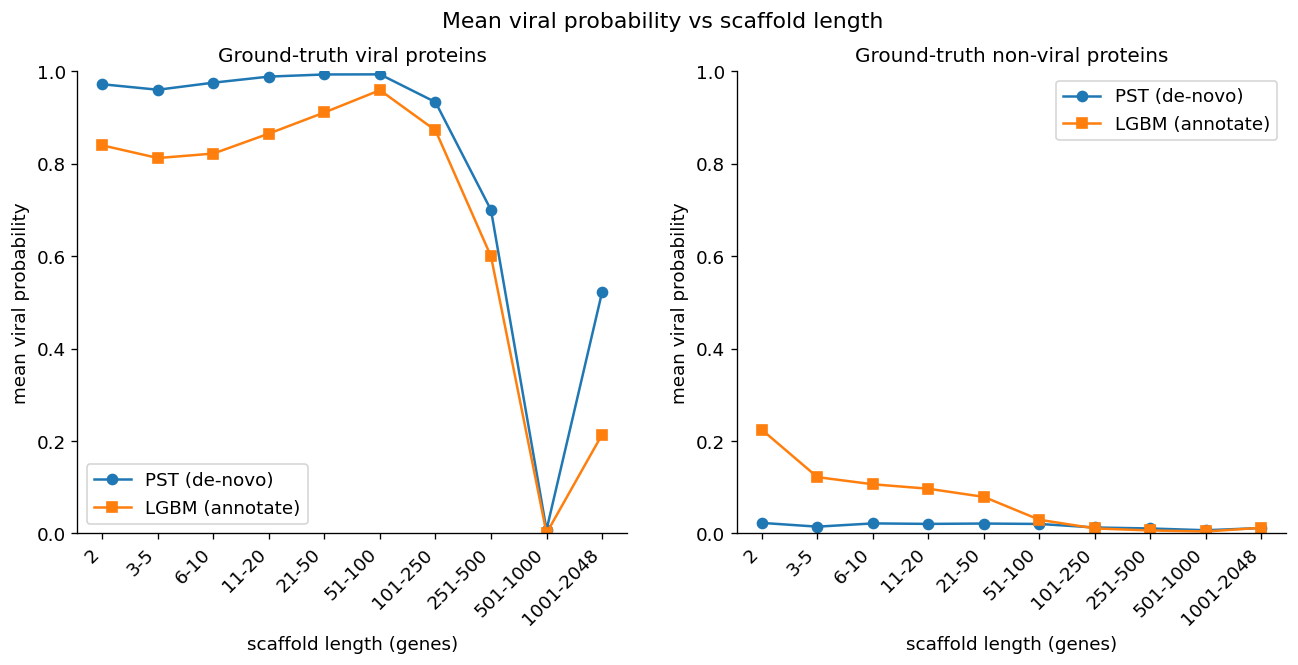

In [12]:
# Per length-bin: mean probability and confidence-tier mix for each model, split by ground truth.
def length_profile(df, klass_name, klass_mask):
    sub = df.filter(klass_mask)
    g = (sub.group_by(["gene_bin_idx", "gene_bin"]).agg(
            n=pl.len(),
            pst_mean=pl.col("Viral prob").mean(),
            lgbm_mean=pl.col("LGBM_prob").mean(),
            pst_called=pl.col("pst_viral_call").mean(),
            lgbm_called=pl.col("lgbm_viral_call").mean(),
         ).sort("gene_bin_idx").with_columns(klass=pl.lit(klass_name)))
    return g

prof = pl.concat([
    length_profile(U, "viral", pl.col("viral")),
    length_profile(U, "non-viral", ~pl.col("viral")),
    length_profile(U, "all", pl.lit(True)),
])
save_tsv(prof, "task2_length_probability_profile.tsv")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
for ax, klass in zip(axes, ["viral", "non-viral"]):
    s = prof.filter(pl.col("klass") == klass).sort("gene_bin_idx")
    x = s["gene_bin_idx"].to_numpy()
    ax.plot(x, s["pst_mean"], "-o", label="PST (de-novo)")
    ax.plot(x, s["lgbm_mean"], "-s", label="LGBM (annotate)")
    ax.set_xticks(x); ax.set_xticklabels(s["gene_bin"], rotation=45, ha="right")
    ax.set_xlabel("scaffold length (genes)")
    ax.set_ylabel("mean viral probability")
    ax.set_title(f"Ground-truth {klass} proteins")
    ax.set_ylim(0, 1); ax.legend()
fig.suptitle("Mean viral probability vs scaffold length")
plt.show()

These curves are computed within each ground-truth class, so they do not depend on how many viral proteins a length bin holds. Among true viral proteins on short scaffolds (2-10 genes), PST already assigns mean viral probability ~0.96-0.98 and recalls ~99%, while LGBM assigns ~0.81-0.84 and recalls 94-96%. The gap widens with length: on the longest scaffolds (1001-2048 genes) PST still recalls 87% of true viral proteins (mean prob 0.52) but LGBM recalls only 3% (mean prob 0.21). The per-class Spearman correlations show why: LGBM's probability rises with scaffold length for viral proteins (rho +0.37) and falls steeply for non-viral proteins (rho -0.38), so its score tracks how much genomic context is available, while PST's is nearly flat for viral proteins (rho +0.10). LGBM needs several neighboring genes to accumulate context evidence, so it loses sensitivity both on gene-sparse short scaffolds and on long host scaffolds where viral genes sit as isolated islands. PST, scoring each protein from its own embedding, barely depends on having informative neighbors. The two longest bins hold only 89 and 116 true viral proteins, so their per-bin means are noisy (PST dips in the 501-1000 bin before recovering), and the robust length trend is the model x length interaction quantified below.

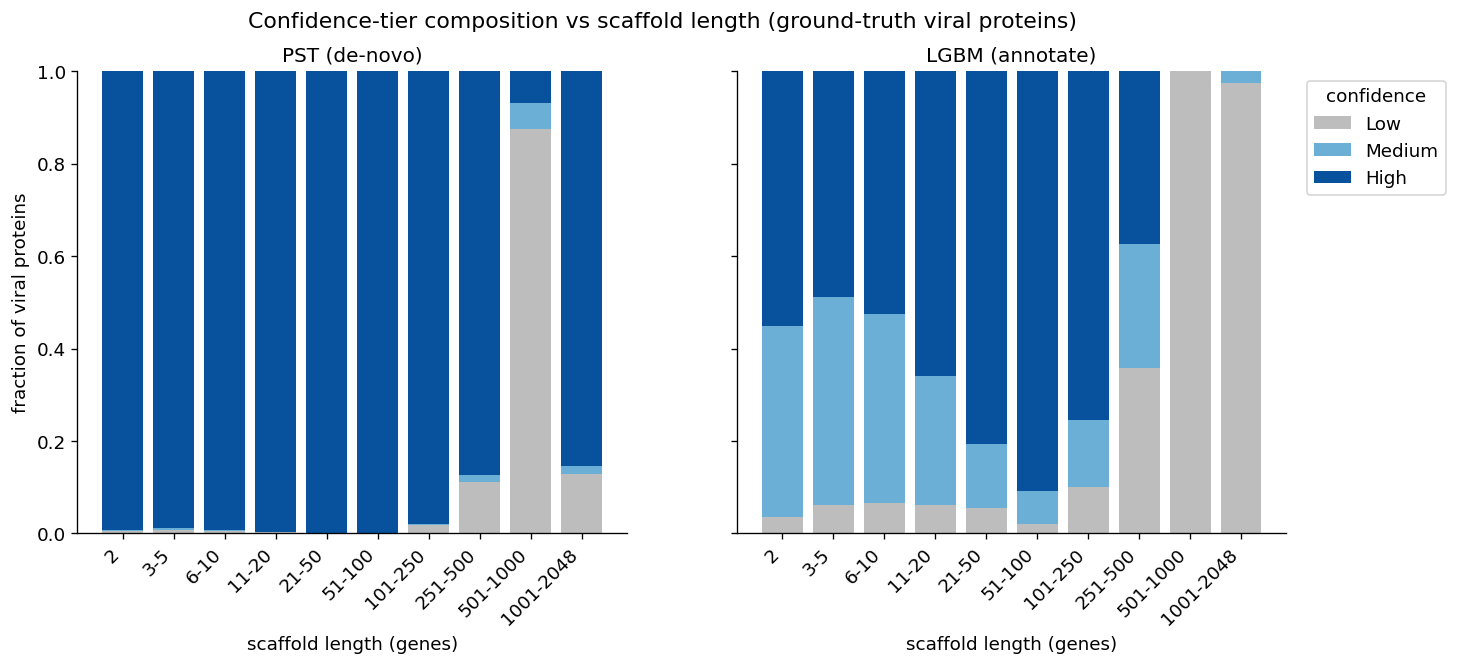

In [13]:
# Confidence-tier composition across length bins (stacked), per model, for ground-truth viral proteins.
viral_df = U.filter(pl.col("viral"))
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
tier_colors = {"Low": "#bdbdbd", "Medium": "#6baed6", "High": "#08519c"}
for ax, col, name in [(axes[0], "pst_conf3", "PST (de-novo)"), (axes[1], "lgbm_conf3", "LGBM (annotate)")]:
    comp = (viral_df.group_by(["gene_bin_idx", "gene_bin", col]).len()
            .with_columns(frac=pl.col("len") / pl.col("len").sum().over(["gene_bin_idx"]))
            .sort("gene_bin_idx"))
    bins = comp.select(["gene_bin_idx", "gene_bin"]).unique().sort("gene_bin_idx")
    x = bins["gene_bin_idx"].to_numpy()
    bottom = np.zeros(len(x))
    for tier in CONF3:
        fr = np.array([comp.filter((pl.col("gene_bin_idx") == i) & (pl.col(col) == tier))["frac"].sum() for i in x])
        ax.bar(x, fr, bottom=bottom, label=tier, color=tier_colors[tier])
        bottom += fr
    ax.set_xticks(x); ax.set_xticklabels(bins["gene_bin"], rotation=45, ha="right")
    ax.set_title(name); ax.set_xlabel("scaffold length (genes)")
axes[0].set_ylabel("fraction of viral proteins")
axes[1].legend(title="confidence", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Confidence-tier composition vs scaffold length (ground-truth viral proteins)")
plt.show()

In [14]:
# Statistical tests of probability-vs-length dependence (Spearman), per model and ground-truth class.
rows = []
for klass_name, mask in [("viral", U["viral"].to_numpy().astype(bool)),
                         ("non-viral", ~U["viral"].to_numpy().astype(bool)),
                         ("all", np.ones(U.height, dtype=bool))]:
    lp = U["log_n_genes"].to_numpy()[mask]
    for model_name, prob in [("PST", U["Viral prob"].to_numpy()[mask]), ("LGBM", U["LGBM_prob"].to_numpy()[mask])]:
        r = ss.spearmanr(lp, prob)
        rows.append({"class": klass_name, "model": model_name, "n": int(mask.sum()),
                     "spearman_prob_vs_log_genes": float(r.statistic), "p_value": float(r.pvalue)})
length_spearman = pl.DataFrame(rows)
save_tsv(length_spearman, "task2_prob_length_spearman.tsv")
length_spearman

wrote /storage2/scratch/kosmopoulos/software/CheckAMG/notebooks/tables/compare_pst_lgbm/task2_prob_length_spearman.tsv (6, 5)


class,model,n,spearman_prob_vs_log_genes,p_value
str,str,i64,f64,f64
"""viral""","""PST""",803865,0.09703,0.0
"""viral""","""LGBM""",803865,0.370599,0.0
"""non-viral""","""PST""",854741,0.005189,0.000002
"""non-viral""","""LGBM""",854741,-0.382998,0.0
"""all""","""PST""",1658606,0.163031,0.0
"""all""","""LGBM""",1658606,0.086117,0.0


Test correctness against scaffold length directly. Fit a logistic regression of per-protein correctness (the medium+ call matching the label) on log gene-count for each model, then an interaction model (`correct ~ log_genes * model`) whose interaction term is non-zero only if the two models differ in their length-dependence.

In [15]:
# Does correctness depend on scaffold length, and is one model more robust?
# correct = predicted-viral (medium+) matches the ground-truth viral label.
U = U.with_columns(
    pst_correct=(pl.col("pst_viral_call") == pl.col("viral")).cast(pl.Int64),
    lgbm_correct=(pl.col("lgbm_viral_call") == pl.col("viral")).cast(pl.Int64),
)
logx = U["log_n_genes"].to_numpy()
def logit_fit(target):
    X = sm.add_constant(logx)
    res = sm.Logit(U[target].to_numpy(), X).fit(disp=0)
    return res.params[1], res.bse[1], res.pvalues[1]

rows = []
for model_name, tgt in [("PST", "pst_correct"), ("LGBM", "lgbm_correct")]:
    b, se, pv = logit_fit(tgt)
    rows.append({"model": model_name, "slope_log_genes": float(b), "std_err": float(se), "p_value": float(pv)})

# Interaction model: correctness ~ log_genes * model. A significant interaction means the
# two models' length-dependence differs (the more robust model has the flatter slope).
long = pl.concat([
    U.select(correct="pst_correct").with_columns(model=pl.lit(0), logg=pl.Series(logx)),
    U.select(correct="lgbm_correct").with_columns(model=pl.lit(1), logg=pl.Series(logx)),
])
Xi = np.column_stack([np.ones(long.height), long["logg"].to_numpy(), long["model"].to_numpy(),
                      long["logg"].to_numpy() * long["model"].to_numpy()])
inter = sm.Logit(long["correct"].to_numpy(), Xi).fit(disp=0)
interaction = {"term": "log_genes:model(LGBM)", "coef": float(inter.params[3]),
               "std_err": float(inter.bse[3]), "p_value": float(inter.pvalues[3])}
length_robust = pl.DataFrame(rows)
save_tsv(length_robust, "task2_correctness_length_logit.tsv")
save_tsv(pl.DataFrame([interaction]), "task2_correctness_length_interaction.tsv")
print(length_robust)
print(interaction)

wrote /storage2/scratch/kosmopoulos/software/CheckAMG/notebooks/tables/compare_pst_lgbm/task2_correctness_length_logit.tsv (2, 4)
wrote /storage2/scratch/kosmopoulos/software/CheckAMG/notebooks/tables/compare_pst_lgbm/task2_correctness_length_interaction.tsv (1, 4)
shape: (2, 4)
┌───────┬─────────────────┬──────────┬──────────┐
│ model ┆ slope_log_genes ┆ std_err  ┆ p_value  │
│ ---   ┆ ---             ┆ ---      ┆ ---      │
│ str   ┆ f64             ┆ f64      ┆ f64      │
╞═══════╪═════════════════╪══════════╪══════════╡
│ PST   ┆ -0.004936       ┆ 0.00385  ┆ 0.199848 │
│ LGBM  ┆ 0.40649         ┆ 0.003162 ┆ 0.0      │
└───────┴─────────────────┴──────────┴──────────┘
{'term': 'log_genes:model(LGBM)', 'coef': 0.41142582831770175, 'std_err': 0.00498242460507499, 'p_value': 0.0}


LGBM's accuracy depends strongly on length (slope 0.41 on log gene-count, p < 1e-300) while PST's is flat and not significant (slope -0.005, p = 0.20). The interaction term is large and highly significant (coef 0.41, p < 1e-300), so the two models genuinely differ in length-dependence and PST is the more length-robust of the two. One caveat motivates the prevalence-aware analysis below: "correct" here is the medium+ call versus the label, so on long, viral-sparse scaffolds a high accuracy partly reflects correctly calling the many non-viral genes rather than viral-origin skill.

### Accounting for viral prevalence across length bins

Very long scaffolds are mostly host chromosomes, where true viral proteins are a tiny minority. AUPRC is prevalence-dependent (a random classifier scores AUPRC equal to the positive prevalence), so it drops mechanically as a bin's viral fraction falls even when the model still ranks viral proteins well. To separate genuine model degradation from this class-balance artifact, the next cell reports, per length bin:

* `viral_prevalence`: the positive fraction, making the imbalance explicit.
* `auroc`: ranking quality, invariant to prevalence (the fair length-robustness metric).
* `norm_auprc = (AUPRC - prevalence) / (1 - prevalence)`: AUPRC rescaled so 0 = random and 1 = perfect at that bin's prevalence.
* `recall_viral` (sensitivity among true viral proteins) and `specificity_nonviral` (true-negative rate among non-viral proteins) at the medium+ tier, both computed within a single class and therefore prevalence-free.

wrote /storage2/scratch/kosmopoulos/software/CheckAMG/notebooks/tables/compare_pst_lgbm/task2_performance_by_length.tsv (10, 15)


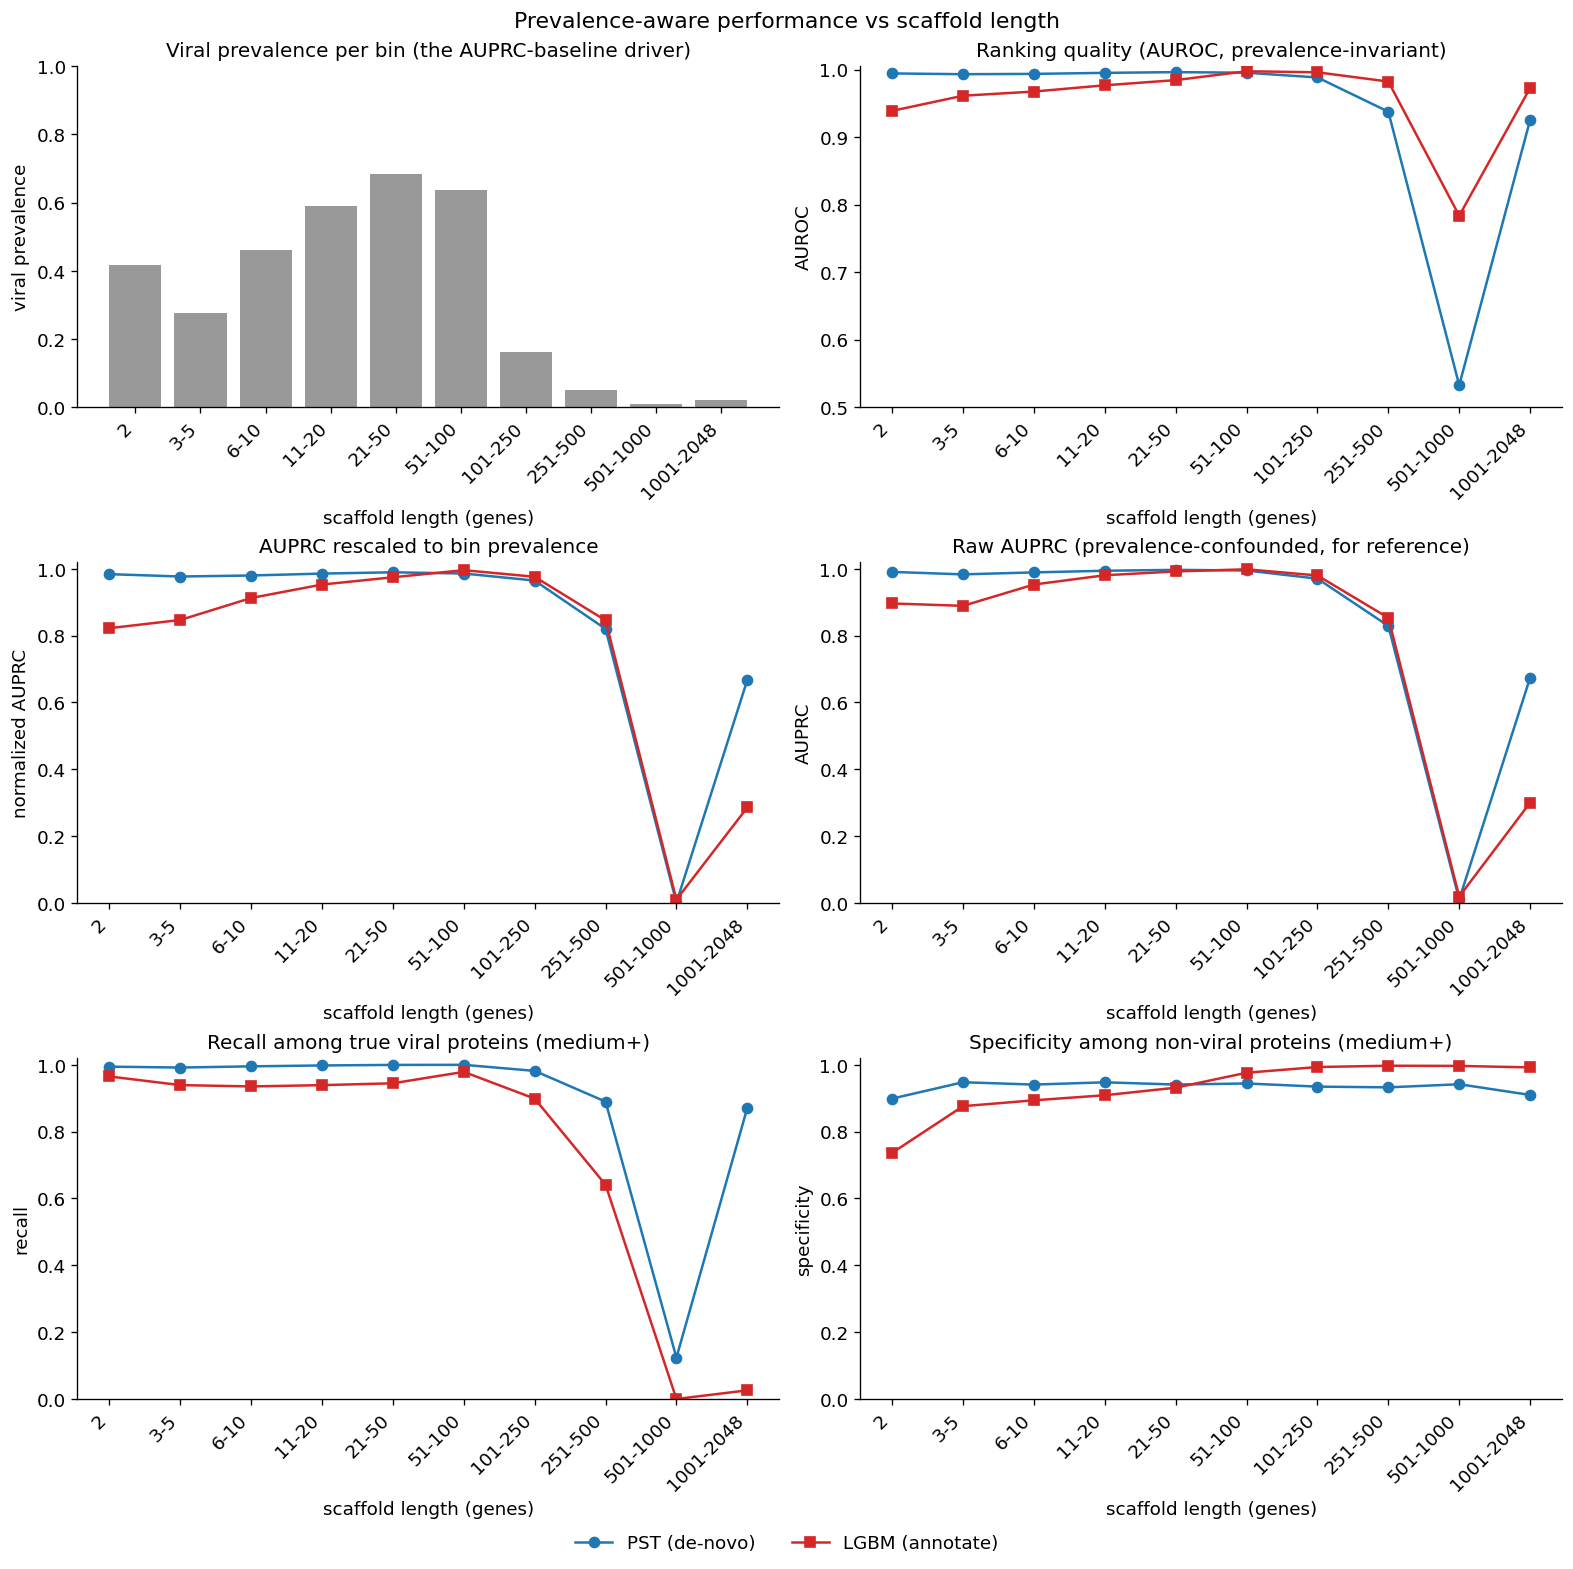

gene_bin,n,n_viral,viral_prevalence,pst_auroc,lgbm_auroc,pst_auprc,lgbm_auprc,pst_norm_auprc,lgbm_norm_auprc,pst_recall_viral,lgbm_recall_viral
str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""2""",29326,12200,0.416013,0.994241,0.93884,0.990583,0.896213,0.983875,0.822278,0.994098,0.964754
"""3-5""",296450,81845,0.276084,0.993116,0.961235,0.983236,0.889084,0.976842,0.846783,0.991423,0.938909
"""6-10""",439632,202601,0.460842,0.993561,0.967418,0.989137,0.952852,0.979852,0.912552,0.99501,0.934842
"""11-20""",376772,221978,0.589157,0.99508,0.97668,0.994065,0.980589,0.985555,0.952753,0.997689,0.938796
"""21-50""",316460,216768,0.684978,0.996177,0.984341,0.996684,0.991986,0.989474,0.974562,0.999303,0.944318
"""51-100""",89321,56920,0.637252,0.995299,0.997469,0.994848,0.998473,0.985796,0.995789,0.999578,0.978514
"""101-250""",59263,9574,0.161551,0.988292,0.995894,0.970422,0.979928,0.964723,0.976061,0.981408,0.898475
"""251-500""",36089,1774,0.049156,0.937577,0.982219,0.829037,0.853205,0.820199,0.845616,0.889515,0.640924
"""501-1000""",9520,89,0.009349,0.532514,0.783538,0.010747,0.019563,0.001412,0.01031,0.123596,0.0


In [16]:
def _rate(mask_num, mask_den):
    d = int(mask_den.sum())
    return float((mask_num & mask_den).sum() / d) if d else float("nan")

rows = []
for i in sorted(U["gene_bin_idx"].unique().to_list()):
    sub = U.filter(pl.col("gene_bin_idx") == i)
    yy = sub["viral"].to_numpy().astype(bool)
    if yy.sum() == 0 or yy.sum() == len(yy):
        continue
    prev = float(yy.mean())
    pst_ap = float(average_precision_score(yy.astype(int), sub["Viral prob"].to_numpy()))
    lgbm_ap = float(average_precision_score(yy.astype(int), sub["LGBM_prob"].to_numpy()))
    pcall = sub["pst_viral_call"].to_numpy(); lcall = sub["lgbm_viral_call"].to_numpy()
    rows.append({
        "gene_bin_idx": i, "gene_bin": sub["gene_bin"][0], "n": len(yy), "n_viral": int(yy.sum()),
        "viral_prevalence": prev,
        "pst_auroc": float(roc_auc_score(yy.astype(int), sub["Viral prob"].to_numpy())),
        "lgbm_auroc": float(roc_auc_score(yy.astype(int), sub["LGBM_prob"].to_numpy())),
        "pst_auprc": pst_ap, "lgbm_auprc": lgbm_ap,
        "pst_norm_auprc": (pst_ap - prev) / (1 - prev), "lgbm_norm_auprc": (lgbm_ap - prev) / (1 - prev),
        "pst_recall_viral": _rate(pcall, yy), "lgbm_recall_viral": _rate(lcall, yy),
        "pst_specificity_nonviral": _rate(~pcall, ~yy), "lgbm_specificity_nonviral": _rate(~lcall, ~yy),
    })
auprc_len = pl.DataFrame(rows).sort("gene_bin_idx")
save_tsv(auprc_len, "task2_performance_by_length.tsv")

x = auprc_len["gene_bin_idx"].to_numpy()
labels = auprc_len["gene_bin"].to_list()
fig, axes = plt.subplots(3, 2, figsize=(13, 13), constrained_layout=True)

# Top-left panel: viral prevalence (the class-balance driver), as its own axis so nothing overlaps.
ax0 = axes[0, 0]
ax0.bar(x, auprc_len["viral_prevalence"], color="0.6")
ax0.set_ylabel("viral prevalence"); ax0.set_ylim(0, 1)
ax0.set_title("Viral prevalence per bin (the AUPRC-baseline driver)")

line_handles = None
def _panel(ax, pcol, lcol, ylab, title, ylim):
    global line_handles
    h1, = ax.plot(x, auprc_len[pcol], "-o", color="#1f77b4", label="PST (de-novo)")
    h2, = ax.plot(x, auprc_len[lcol], "-s", color="#d62728", label="LGBM (annotate)")
    ax.set_ylabel(ylab); ax.set_title(title); ax.set_ylim(*ylim)
    line_handles = [h1, h2]

_panel(axes[0, 1], "pst_auroc", "lgbm_auroc", "AUROC", "Ranking quality (AUROC, prevalence-invariant)", (0.5, 1.005))
_panel(axes[1, 0], "pst_norm_auprc", "lgbm_norm_auprc", "normalized AUPRC", "AUPRC rescaled to bin prevalence", (0, 1.02))
_panel(axes[1, 1], "pst_auprc", "lgbm_auprc", "AUPRC", "Raw AUPRC (prevalence-confounded, for reference)", (0, 1.02))
_panel(axes[2, 0], "pst_recall_viral", "lgbm_recall_viral", "recall", "Recall among true viral proteins (medium+)", (0, 1.02))
_panel(axes[2, 1], "pst_specificity_nonviral", "lgbm_specificity_nonviral", "specificity", "Specificity among non-viral proteins (medium+)", (0, 1.02))

for ax in axes.flat:
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_xlabel("scaffold length (genes)")
fig.legend(handles=line_handles, loc="outside lower center", ncol=2, frameon=False)
fig.suptitle("Prevalence-aware performance vs scaffold length")
plt.show()
auprc_len.select(["gene_bin", "n", "n_viral", "viral_prevalence", "pst_auroc", "lgbm_auroc",
                  "pst_auprc", "lgbm_auprc", "pst_norm_auprc", "lgbm_norm_auprc",
                  "pst_recall_viral", "lgbm_recall_viral"])

The raw AUPRC dip on long scaffolds is mostly a class-balance artifact, as suspected. Viral prevalence peaks near 68% on mid-length scaffolds and collapses to ~1-2% on the longest (1001-2048 genes), which by itself forces AUPRC down. AUROC, which is invariant to prevalence, stays high for both models across the well-populated bins (both above 0.94 through 251-500 genes). The prevalence-free differences are in the medium+ calls: PST's specificity on non-viral proteins is stable across lengths (~0.90-0.95), while LGBM's is low on gene-sparse short scaffolds (0.74 at 2 genes) and climbs to ~0.99 on long scaffolds, and PST holds recall of the true viral proteins where LGBM does not (on 1001-2048-gene scaffolds, recall 0.87 vs 0.03). So LGBM over-calls on short scaffolds that lack context, then as context accumulates on long host chromosomes it trades viral recall for specificity and stops recovering the rare embedded viral genes, while PST stays balanced at both extremes. The two highest-gene bins hold only ~90-120 true viral proteins each and are correspondingly noisy (PST's AUROC even dips in the 501-1000 bin), but the pattern is consistent with the length-robustness result above. This is the regime that matters most for metagenomic AMG discovery, where viral and auxiliary genes have to be pulled out of host-dominated contigs.

## Part 3: AVG-call agreement between `annotate` and `de-novo`

`de-novo` calls a protein an AVG from its effective AVG probability `eff_avg_prob = AVG-like prob * Viral prob` (an AND-gate on AVG homology and viral origin), tiered by the PST AVG cutoffs. `annotate` calls a protein an AVG when it is homologous to an AMG/APG/AReG model (the `Protein Classification`) and passes its rule-based viral-origin curation, summarized by `Protein Viral Origin Confidence`. Confirm first that the PST `AVG` label is the uncurated homology class, so AVG disagreement is about the viral origin of the same homologs plus de-novo calls outside the homolog set.

In [17]:
U = U.with_columns(
    homolog=pl.col("AVG"),
    annot_class=pl.col("Protein Classification"),
    voc=pl.col("Protein Viral Origin Confidence"),
)
# Confirm PST AVG label == annotate homology classification (uncurated).
check = U.with_columns(cls_avg=pl.col("annot_class").is_in(["metabolic", "regulatory", "physiological"]))
xt = check.group_by(["AVG", "cls_avg"]).len().sort(["AVG", "cls_avg"])
print(xt)
print("PST AVG label identical to annotate homology class:",
      check.select((pl.col("AVG") == pl.col("cls_avg")).all()).item())

shape: (2, 3)
┌───────┬─────────┬─────────┐
│ AVG   ┆ cls_avg ┆ len     │
│ ---   ┆ ---     ┆ ---     │
│ bool  ┆ bool    ┆ u64     │
╞═══════╪═════════╪═════════╡
│ false ┆ false   ┆ 1518750 │
│ true  ┆ true    ┆ 139856  │
└───────┴─────────┴─────────┘
PST AVG label identical to annotate homology class: True


The PST `AVG` label equals the `annotate` homology classification (metabolic / regulatory / physiological) for every protein, with no curation applied. This fixes what the comparison can mean. Any protein `annotate` calls an AVG must be a homolog, so the two modules can only disagree about whether a given homolog is genuinely viral, or about AVGs `de-novo` calls outside the homolog set. They are two viral-origin gates applied to (largely) the same homology evidence, not two independent ways of recognizing AVG function, so every disagreement below is about viral origin and not about what counts as an auxiliary gene.

In [18]:
# AVG calls at the medium+ tier.
# de-novo: eff_avg_prob >= PST AVG medium cutoff.
# annotate (curated): homolog and Viral_Origin_Confidence in {medium, high}.
U = U.with_columns(
    denovo_avg=pl.col("eff_avg_prob") >= PST_AVG["medium"],
    annot_avg=pl.col("AVG") & pl.col("voc").is_in(["medium", "high"]),
)
da = U["denovo_avg"].to_numpy(); aa = U["annot_avg"].to_numpy(); hom = U["AVG"].to_numpy()
def setrow(scope, m_da, m_aa):
    both = int((m_da & m_aa).sum()); d_only = int((m_da & ~m_aa).sum())
    a_only = int((~m_da & m_aa).sum()); neither = int((~m_da & ~m_aa).sum())
    union = both + d_only + a_only
    return {"scope": scope, "both": both, "denovo_only": d_only, "annotate_only": a_only, "neither": neither,
            "jaccard": both / union if union else 0.0,
            "denovo_total": both + d_only, "annotate_total": both + a_only,
            "frac_annotate_within_denovo": both / (both + a_only) if (both + a_only) else float("nan"),
            "frac_denovo_within_annotate": both / (both + d_only) if (both + d_only) else float("nan")}
avg_sets = pl.DataFrame([
    setrow("all proteins", da, aa),
    setrow("homologs only", da & hom, aa & hom),
])
save_tsv(avg_sets, "task3_avg_set_agreement.tsv")
avg_sets

wrote /storage2/scratch/kosmopoulos/software/CheckAMG/notebooks/tables/compare_pst_lgbm/task3_avg_set_agreement.tsv (2, 10)


scope,both,denovo_only,annotate_only,neither,jaccard,denovo_total,annotate_total,frac_annotate_within_denovo,frac_denovo_within_annotate
str,i64,i64,i64,i64,f64,i64,i64,f64,f64
"""all proteins""",8588,8265,2277,1639476,0.448928,16853,10865,0.790428,0.509583
"""homologs only""",8588,2399,2277,1645342,0.647467,10987,10865,0.790428,0.781651


`de-novo` calls 16,853 AVGs and `annotate` 10,865, sharing 8,588. Among homologs (the only set where both can operate) agreement is moderate: Jaccard 0.65, with 2,399 `de-novo`-only and 2,277 `annotate`-only. Neither module encompasses the other: 79% of `annotate`'s AVGs are also `de-novo` calls, but only 78% of `de-novo`'s homolog AVGs are also `annotate` calls (51% once the non-homolog calls are included). So the modules concur on most confident AVGs but each contributes a few thousand unique calls. Against ~1.6M proteins the contested set is small, and the cells below show each unique set has a single dominant cause.

### What de-novo finds that annotate cannot

In [19]:
# annotate can only call AVGs among homologs; de-novo can call AVGs on proteins with no AVG homology.
nonhom = U.filter(pl.col("denovo_avg") & ~pl.col("AVG"))
summary = pl.DataFrame([{
    "denovo_avg_total": int(da.sum()),
    "denovo_avg_homolog": int((da & hom).sum()),
    "denovo_avg_nonhomolog": int((da & ~hom).sum()),
    "frac_nonhomolog": float((da & ~hom).sum() / da.sum()) if da.sum() else float("nan"),
    "nonhom_median_viral_prob": float(nonhom["Viral prob"].median()),
    "nonhom_median_avglike_prob": float(nonhom["AVG-like prob"].median()),
    "nonhom_frac_ground_truth_viral": float(nonhom["viral"].mean()),
}])
save_tsv(summary, "task3_denovo_nonhomolog_avg.tsv")
summary

wrote /storage2/scratch/kosmopoulos/software/CheckAMG/notebooks/tables/compare_pst_lgbm/task3_denovo_nonhomolog_avg.tsv (1, 7)


denovo_avg_total,denovo_avg_homolog,denovo_avg_nonhomolog,frac_nonhomolog,nonhom_median_viral_prob,nonhom_median_avglike_prob,nonhom_frac_ground_truth_viral
i64,i64,i64,f64,f64,f64,f64
16853,10987,5866,0.348069,1.0,0.48305,0.922093


35% of `de-novo`'s AVG calls (5,866) fall on proteins with no AVG homology, which `annotate` cannot call by construction. These have median viral probability 1.0 and are 92% genuinely viral, with a moderate AVG-like probability (median 0.48): PST is flagging confidently-viral genes whose embeddings resemble known AVGs without any hit to an AVG HMM. This is what the embedding-based module adds, candidate auxiliary genes beyond the reach of the homology databases `annotate` depends on. They cannot be corroborated by homology, though, so some fraction are genuine novel AVGs and some are over-calls, and they are best treated as a candidate list for downstream validation rather than finished annotations.

### Why the modules disagree among homologs

In [20]:
# Among homologs, contrast the contextual signals annotate uses across the four agreement cells.
# AVG array length = number of homologs in the protein's viral region.
arr = (U.filter(pl.col("AVG") & pl.col("viral_region_id").is_not_null() & (pl.col("viral_region_id") >= 0))
       .group_by(["contig", "viral_region_id"]).agg(avg_array_len=pl.len()))
H = (U.filter(pl.col("AVG"))
     .join(arr, on=["contig", "viral_region_id"], how="left")
     .with_columns(avg_array_len=pl.col("avg_array_len").fill_null(1),
                   end_dist=pl.min_horizontal("contig_left_end_gene_dist", "contig_right_end_gene_dist")))
def cell(r):
    return ("both" if (r["denovo_avg"] and r["annot_avg"]) else
            "denovo_only" if (r["denovo_avg"] and not r["annot_avg"]) else
            "annotate_only" if (r["annot_avg"] and not r["denovo_avg"]) else "neither")
H = H.with_columns(cell=pl.struct(["denovo_avg", "annot_avg"]).map_elements(cell, return_dtype=pl.Utf8))

disag = (H.group_by("cell").agg(
    n=pl.len(),
    frac_voc_low=(pl.col("voc") == "low").mean(),
    frac_voc_high=(pl.col("voc") == "high").mean(),
    frac_in_strict_region=pl.col("step5_in_merged_region").fill_null(False).mean(),
    median_end_dist_genes=pl.col("end_dist").median(),
    median_avg_array_len=pl.col("avg_array_len").median(),
    median_pst_viral_prob=pl.col("Viral prob").median(),
    median_lgbm_prob=pl.col("LGBM_prob").median(),
).sort("n", descending=True))
save_tsv(disag, "task3_homolog_disagreement_context.tsv")
disag

wrote /storage2/scratch/kosmopoulos/software/CheckAMG/notebooks/tables/compare_pst_lgbm/task3_homolog_disagreement_context.tsv (4, 9)


cell,n,frac_voc_low,frac_voc_high,frac_in_strict_region,median_end_dist_genes,median_avg_array_len,median_pst_viral_prob,median_lgbm_prob
str,u64,f64,f64,f64,f32,f64,f64,f64
"""neither""",126592,1.0,0.0,0.063598,1.0,1.0,0.0,0.001701
"""both""",8588,0.0,0.709013,0.640196,3.0,1.0,1.0,0.976297
"""denovo_only""",2399,1.0,0.0,0.286369,2.0,1.0,0.9519,0.121801
"""annotate_only""",2277,0.0,0.389108,0.393061,1.0,1.0,0.9541,0.840956


In [21]:
# Test: among homologs, are de-novo-only calls enriched for annotate-low viral-origin confidence
# (i.e. annotate excluded them on context), and are annotate-only calls de-novo-low on viral prob?
denovo_only = H.filter(pl.col("cell") == "denovo_only")
annot_only = H.filter(pl.col("cell") == "annotate_only")
both = H.filter(pl.col("cell") == "both")

# de-novo-only vs both: VOC distribution (chi-square).
tab = (H.filter(pl.col("cell").is_in(["denovo_only", "both"]))
       .group_by(["cell", "voc"]).len()
       .pivot(values="len", index="voc", on="cell").fill_null(0))
arr2 = tab.select([c for c in ["denovo_only", "both"] if c in tab.columns]).to_numpy()
chi2, pchi, _, _ = ss.chi2_contingency(arr2)
# annotate-only vs both: PST viral prob (Mann-Whitney).
mw = ss.mannwhitneyu(annot_only["Viral prob"].to_numpy(), both["Viral prob"].to_numpy(), alternative="less")
tests = pl.DataFrame([
    {"test": "denovo_only vs both: VOC distribution (chi-square)", "statistic": float(chi2), "p_value": float(pchi)},
    {"test": "annotate_only PST viral prob < both (Mann-Whitney)", "statistic": float(mw.statistic), "p_value": float(mw.pvalue)},
])
save_tsv(tests, "task3_disagreement_tests.tsv")
print(tab)
tests

wrote /storage2/scratch/kosmopoulos/software/CheckAMG/notebooks/tables/compare_pst_lgbm/task3_disagreement_tests.tsv (2, 3)
shape: (3, 3)
┌────────┬─────────────┬──────┐
│ voc    ┆ denovo_only ┆ both │
│ ---    ┆ ---         ┆ ---  │
│ str    ┆ u64         ┆ u64  │
╞════════╪═════════════╪══════╡
│ low    ┆ 2399        ┆ 0    │
│ high   ┆ 0           ┆ 6089 │
│ medium ┆ 0           ┆ 2499 │
└────────┴─────────────┴──────┘


test,statistic,p_value
str,f64,f64
"""denovo_only vs both: VOC distribution (chi-square)""",10987.0,0.0
"""annotate_only PST viral prob < both (Mann-Whitney)""",5146996.5,0.0


The two homolog disagreements have opposite, clean signatures. The `de-novo`-only homologs are 100% `annotate`-low viral-origin confidence (versus 71% `annotate`-high for the shared "both" set, chi-square p < 1e-300): `annotate` saw these homologs but its curation judged their viral origin too weak (median LGBM context probability 0.12), while PST's embedding still scored them viral (median 0.95). So `de-novo`-only AVGs are the homologs `annotate` deliberately excludes on genomic-context grounds, and from Part 1 PST is usually right when it overrides weak context. The `annotate`-only homologs are the mirror image: `annotate` is confidently viral (median LGBM prob 0.84) but PST missed them, for the reason in the next cell. Both trace to how each module establishes viral origin, never to homology.

### Training rarity of the AVGs de-novo misses

In [22]:
# de-novo learned the homology label from training AVGs. annotate-only calls are AVGs de-novo missed;
# test whether their homolog family is rare in the PST training data.
train = (pl.read_parquet(TRAIN_PARQUET, columns=["Protein", "AVG"])
         .filter(pl.col("AVG"))
         .with_columns(protein_orig=pl.col("Protein").str.replace(r"_part\d+(_\d+)$", r"${1}")))
fr_hmm = pl.concat([
    pl.scan_parquet(GEN / "final_results.parquet").select(["Protein", "Best Scoring HMM"]),
    pl.scan_parquet(PRO / "final_results.parquet").select(["Protein", "Best Scoring HMM"]),
]).unique(subset=["Protein"], keep="first").collect()
train = train.join(fr_hmm, left_on="protein_orig", right_on="Protein", how="left")
hmm_freq = (train.group_by("Best Scoring HMM").len().rename({"len": "train_count"}))
print("training AVG homologs:", train.height, "| distinct HMMs:", hmm_freq.height)

H2 = H.join(hmm_freq, on="Best Scoring HMM", how="left").with_columns(train_count=pl.col("train_count").fill_null(0))
rar = (H2.filter(pl.col("cell").is_in(["annotate_only", "both"]))
       .group_by("cell").agg(
           n=pl.len(),
           median_train_count=pl.col("train_count").median(),
           frac_rare_lt10=(pl.col("train_count") < 10).mean(),
           frac_absent=(pl.col("train_count") == 0).mean(),
           median_avglike_prob=pl.col("AVG-like prob").median(),
       ).sort("cell"))
save_tsv(rar, "task3_training_rarity.tsv")
mw2 = ss.mannwhitneyu(
    H2.filter(pl.col("cell") == "annotate_only")["train_count"].to_numpy(),
    H2.filter(pl.col("cell") == "both")["train_count"].to_numpy(), alternative="less")
print("annotate_only training count < both (Mann-Whitney): p =", mw2.pvalue)
rar

training AVG homologs: 1397230 | distinct HMMs: 25163
wrote /storage2/scratch/kosmopoulos/software/CheckAMG/notebooks/tables/compare_pst_lgbm/task3_training_rarity.tsv (2, 6)
annotate_only training count < both (Mann-Whitney): p = 8.006987761722795e-137


cell,n,median_train_count,frac_rare_lt10,frac_absent,median_avglike_prob
str,u64,f64,f64,f64,f64
"""annotate_only""",2277,170.0,0.144928,0.031621,0.0
"""both""",8588,443.0,0.017583,0.001747,1.0


The `annotate`-only AVGs, the homologs PST failed to call, have AVG-like probability essentially zero (median 0.0), and their homolog families are much rarer in PST's training data: median 170 training examples versus 443 for the shared AVGs, with 14% from families seen fewer than 10 times (versus 1.8%) and 3% from families absent entirely (Mann-Whitney p = 8e-137). So PST's misses are a training-coverage limitation, not a viral-origin disagreement, since the model never learned the AVG-like signal for under-represented families. These are recoverable by adding training examples for rare AVG families, and in production they are exactly where deferring to `annotate`'s homology-based call is the safe choice. The two modules are complementary: `annotate` anchors the rare, well-characterized families PST under-samples, while `de-novo` extends coverage to context-excluded and non-homologous candidates.

### Disagreement by category and function

In [23]:
# Is disagreement widespread or concentrated in particular AVG categories/functions?
by_cat = (H.filter(pl.col("cell") != "neither")
          .group_by(["annot_class", "cell"]).len()
          .pivot(values="len", index="annot_class", on="cell").fill_null(0).sort("annot_class"))
save_tsv(by_cat, "task3_disagreement_by_category.tsv")

top_funcs = (H.filter(pl.col("cell").is_in(["denovo_only", "annotate_only"]))
             .group_by(["cell", "Function"]).len()
             .sort(["cell", "len"], descending=[False, True]))
top_funcs_out = pl.concat([
    top_funcs.filter(pl.col("cell") == "denovo_only").head(20),
    top_funcs.filter(pl.col("cell") == "annotate_only").head(20),
])
save_tsv(top_funcs_out, "task3_disagreement_top_functions.tsv")
print(by_cat)
top_funcs_out

wrote /storage2/scratch/kosmopoulos/software/CheckAMG/notebooks/tables/compare_pst_lgbm/task3_disagreement_by_category.tsv (3, 4)
wrote /storage2/scratch/kosmopoulos/software/CheckAMG/notebooks/tables/compare_pst_lgbm/task3_disagreement_top_functions.tsv (40, 3)
shape: (3, 4)
┌───────────────┬─────────────┬──────┬───────────────┐
│ annot_class   ┆ denovo_only ┆ both ┆ annotate_only │
│ ---           ┆ ---         ┆ ---  ┆ ---           │
│ str           ┆ u64         ┆ u64  ┆ u64           │
╞═══════════════╪═════════════╪══════╪═══════════════╡
│ metabolic     ┆ 1247        ┆ 1547 ┆ 653           │
│ physiological ┆ 384         ┆ 983  ┆ 352           │
│ regulatory    ┆ 768         ┆ 6058 ┆ 1272          │
└───────────────┴─────────────┴──────┴───────────────┘


cell,Function,len
str,str,u64
"""denovo_only""","""transcriptional regulator""",55
"""denovo_only""","""anti-restriction protein""",49
"""denovo_only""","""parB, spo0J; ParB family transcriptional regulator, chromosome partitioning prot…",48
"""denovo_only""","""transcriptional repressor""",45
"""denovo_only""","""DNA binding protein""",43
"""denovo_only""","""PSMD10; 26S proteasome non-ATPase regulatory subunit 10""",40
"""denovo_only""","""gmd, GMDS; GDPmannose 4,6-dehydratase [EC:4.2.1.47]""",40
"""denovo_only""","""Poxvirus Late Transcription Factor VLTF3 like""",34
"""denovo_only""","""groEL, HSPD1, HSP60, CPN60; chaperonin GroEL [EC:5.6.1.7]""",28


Disagreement is not a uniform offset across AVG types. The per-category and top-function tables localize it to specific homolog families rather than spreading it evenly, consistent with the two mechanisms above: context-based exclusion for the `de-novo`-only set and training rarity for the `annotate`-only set. AVG disagreement is bounded and explainable: among ~1.6M proteins only a few thousand are contested, each contested set has a clear single cause, and the two modules are complementary rather than contradictory.

## Summary numbers

Part 1, viral probability and confidence. The two probabilities are strongly correlated (Pearson 0.89, Spearman 0.84) and the confidence tiers agree 77.6% of the time (linear-weighted kappa 0.74), even though the models share no inputs. Disagreement is asymmetric: PST is the more confident module (it out-ranks LGBM ~5:1) and the more correct one when they diverge (PST-only viral calls 60% correct versus LGBM-only 1.9%), with higher recall at higher precision and a 97.5%-precise shared core of 775k calls. PST is the more sensitive and more precise viral-origin caller here.

Part 2, scaffold length. PST is the more length-robust model: the correctness slope on log gene-count is flat and non-significant for PST (-0.005) versus 0.41 for LGBM, with a highly significant model x length interaction. The raw AUPRC dip on long scaffolds is mostly a prevalence artifact, since viral genes are rare on long host chromosomes. After correcting for prevalence with AUROC, normalized AUPRC, and per-class recall/specificity, PST stays balanced at both length extremes while LGBM over-calls on context-poor short scaffolds (specificity 0.74 at 2 genes) and loses recall of the rare viral genes embedded in long host scaffolds (~0.03 versus PST ~0.87 on 1001-2048-gene scaffolds). PST's per-protein scoring does not need informative gene neighbors, which matters most in the fragmented, host-dominated contigs that are hardest for metagenomic AMG discovery.

Part 3, AVG calls. The PST `AVG` label is the uncurated homology class, so AVG disagreement is about the viral origin of the same homologs, not about homology. The modules agree on most confident AVGs (Jaccard 0.65 among homologs) and neither encompasses the other. The disagreements are bounded and each has one clear cause: `de-novo` additionally calls 5,866 AVGs outside the homolog set (92% genuinely viral) that `annotate` cannot reach, `de-novo`-only homolog calls are entirely the homologs `annotate` excludes on weak genomic context (where PST is usually right), and `annotate`-only calls are AVG families too rare in PST's training data for it to recognize. The two modules are complementary: `annotate` anchors rare well-characterized families and `de-novo` extends coverage to context-excluded and non-homologous candidates.